# 04 Validation Interpretation
## 검증과 해석

### Final Summary
최종 판단에 쓰는 숫자만 한 표로 모은다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:,.4f}".format)

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "outputs" / "tables").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def load_table(name: str) -> pd.DataFrame:
    return pd.read_csv(TABLE_DIR / name)

def show_saved_figure(fig, name: str) -> None:
    path = FIGURE_DIR / name
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))

In [2]:
summary = load_table("final_interpretation_summary.csv")
summary_view = summary[
    [
        "estimand",
        "observed_2025_equal_gap_event_minus_pre",
        "immediate_beta0",
        "cumulative_lag_0_3",
        "end_centered_post_end_mean_e_plus_1_to_3",
        "permutation_percentile",
        "empirical_p_value_upper_tail",
    ]
].rename(
    columns={
        "observed_2025_equal_gap_event_minus_pre": "observed_2025_event_minus_pre",
        "end_centered_post_end_mean_e_plus_1_to_3": "post_end_mean_e1_to_e3",
    }
)
summary_view

,estimand,observed_2025_event_minus_pre,immediate_beta0,cumulative_lag_0_3,post_end_mean_e1_to_e3,permutation_percentile,empirical_p_value_upper_tail
0,accommodation-and-food-service relative response,0.1453,-0.0036,0.1667,0.0989,95.8000,0.0430


관찰된 2025년 상승과 종료 후 지속성은 보이지만, 이것을 레스토랑 단독 인과효과나 상환능력으로 직접 번역하지 않는다.

### Placebo Test
가짜 정책 시점과 가짜 고노출 부문에서도 비슷한 상승이 나오는지 비교한다.

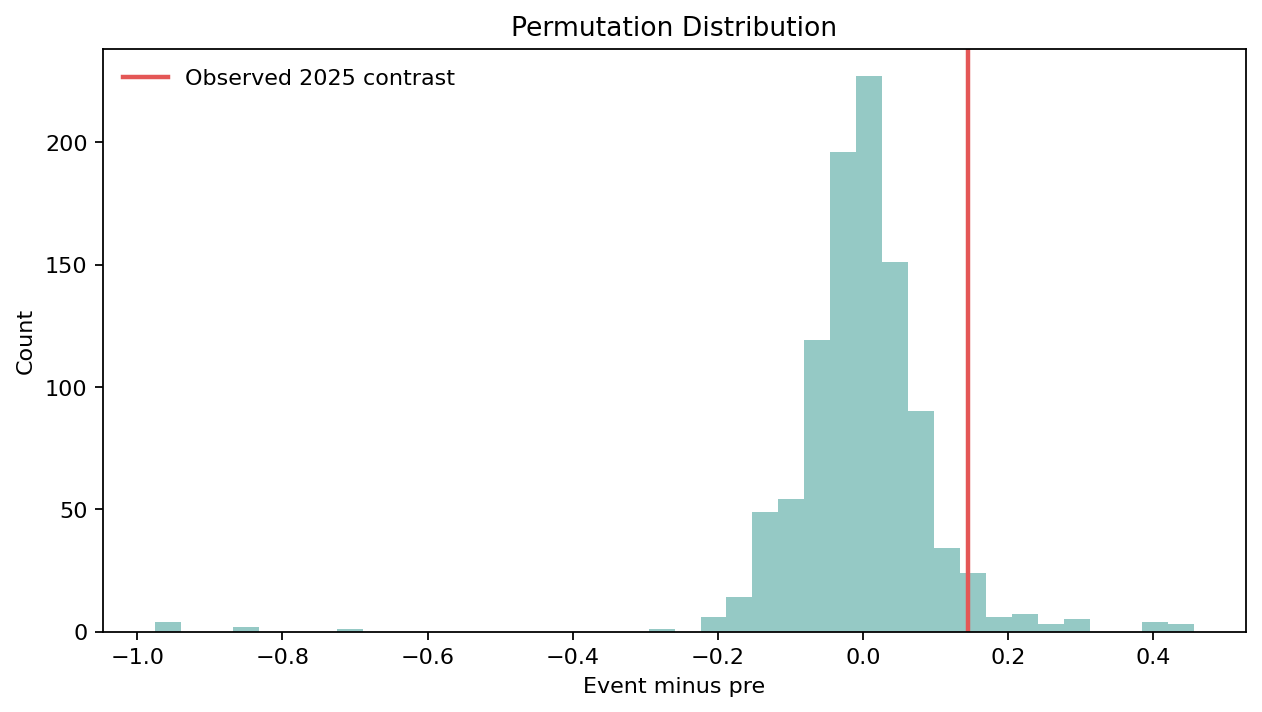

,observed,permutation_median,permutation_percentile,upper_tail_p_value
0,0.1453,-0.0008,95.8000,0.0430


In [3]:
permutation = load_table("permutation_results.csv")
observed = summary.loc[0, "observed_2025_equal_gap_event_minus_pre"]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.hist(permutation["event_minus_pre"], bins=40, color="#72B7B2", alpha=0.75)
ax.axvline(observed, color="#E45756", linewidth=2, label="Observed 2025 contrast")
ax.set_title("Permutation Distribution")
ax.set_xlabel("Event minus pre")
ax.set_ylabel("Count")
ax.legend(frameon=False)
show_saved_figure(fig, "portfolio_permutation_distribution.png")

pd.DataFrame(
    {
        "observed": [observed],
        "permutation_median": [summary.loc[0, "permutation_median"]],
        "permutation_percentile": [summary.loc[0, "permutation_percentile"]],
        "upper_tail_p_value": [summary.loc[0, "empirical_p_value_upper_tail"]],
    }
)

관찰값은 가짜 분포의 상단에 있지만, 공공 집계자료만으로 강한 정책효과라고 단정하기에는 제한이 남는다.

### Robustness Grid
비교 부문, 지연 길이, 통제 변수, 정책 블록 정의를 바꿔도 방향이 유지되는지 확인한다.

In [4]:
robustness = load_table("robustness_grid_results.csv")
ok = robustness[robustness["status"] == "ok"].copy()

robustness_summary = (
    ok.groupby(["comparator", "controls"])
    .agg(
        specs=("status", "size"),
        median_cumulative_lag_0_3=("cumulative_policy_lags", "median"),
        q25=("cumulative_policy_lags", lambda s: s.quantile(0.25)),
        q75=("cumulative_policy_lags", lambda s: s.quantile(0.75)),
    )
    .reset_index()
    .sort_values(["comparator", "controls"])
)
robustness_summary.head(12)

,comparator,controls,specs,median_cumulative_lag_0_3,q25,q75
0,A_main,full_no_pci,160,0.2030,0.1157,0.8774
1,A_main,full_with_pci,160,0.0813,-0.3971,0.3096
2,A_main,month_fe,160,0.0504,-0.6191,1.9791
3,A_main,price,160,-0.0088,-0.7557,1.4620
4,A_main,tourism,160,0.1983,0.1140,0.8240
5,B_fin_real,full_no_pci,160,0.2905,0.1282,0.9958
6,B_fin_real,full_with_pci,160,0.1048,-0.3001,0.3434
7,B_fin_real,month_fe,160,0.0620,-0.6485,2.2297
8,B_fin_real,price,160,0.0352,-0.6651,5.5881
9,B_fin_real,tourism,160,0.2630,0.1292,1.0129


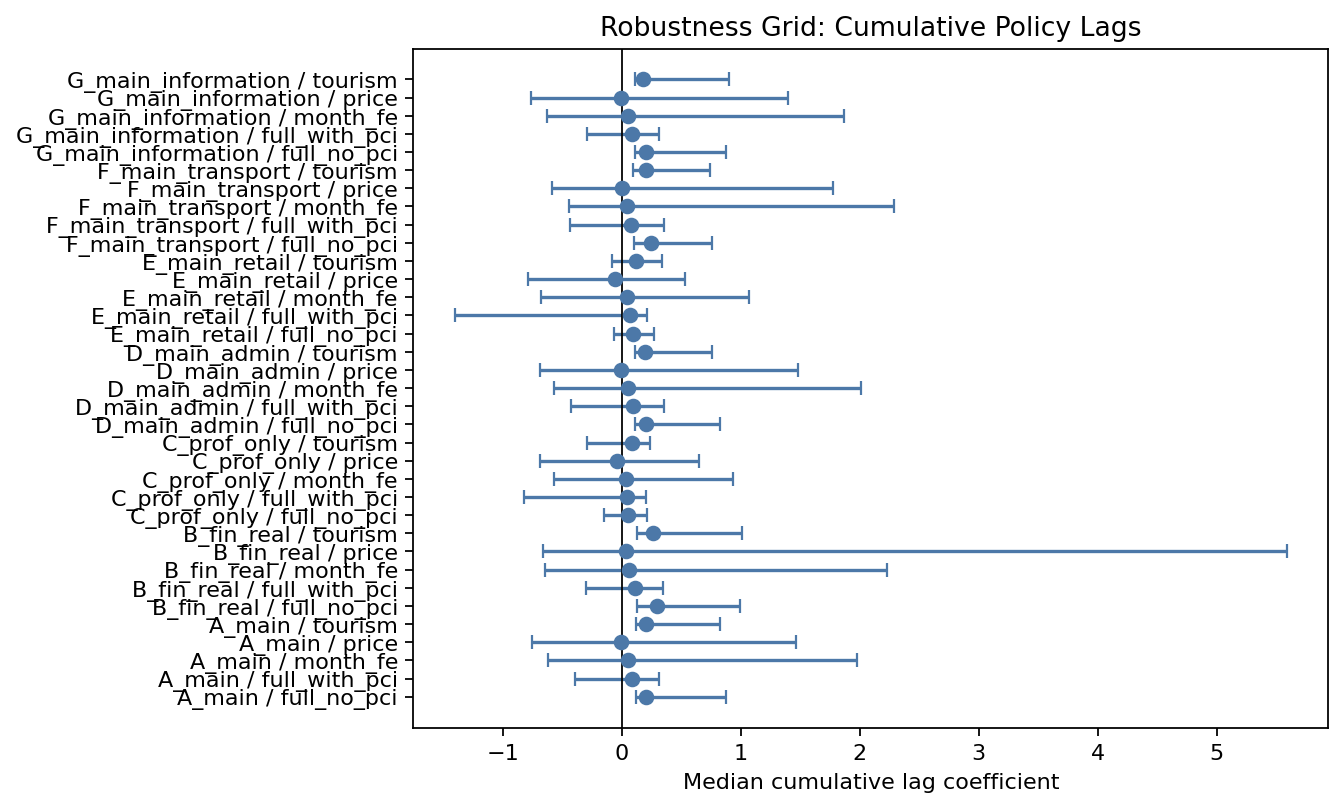

In [5]:
plot_data = robustness_summary.copy()
plot_data["label"] = plot_data["comparator"] + " / " + plot_data["controls"]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(plot_data))
ax.errorbar(
    plot_data["median_cumulative_lag_0_3"],
    y,
    xerr=[
        plot_data["median_cumulative_lag_0_3"] - plot_data["q25"],
        plot_data["q75"] - plot_data["median_cumulative_lag_0_3"],
    ],
    fmt="o",
    capsize=3,
    color="#4C78A8",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y)
ax.set_yticklabels(plot_data["label"])
ax.set_title("Robustness Grid: Cumulative Policy Lags")
ax.set_xlabel("Median cumulative lag coefficient")
show_saved_figure(fig, "portfolio_robustness_grid.png")

강건성 검증은 방향과 민감도를 함께 보는 용도이며, 단일 계수 하나로 결론을 내리지 않는다.

### Credit Decision Implication
외부 정책으로 오른 매출을 그대로 상환 여력으로 보지 않는다.

In [6]:
decision = summary[["safe_interpretation", "overclaim_to_avoid"]].T
decision.columns = ["portfolio_note"]
decision

,portfolio_note
safe_interpretation,Dynamic relative response and persistence/carr...
overclaim_to_avoid,"Do not call this a restaurant-services effect,..."


운영 판단은 정책 민감 매출과 반복 구매·자발 수요를 분리해 보는 쪽이다. 정책 직후 매출 상승은 한도 확대의 단독 근거가 아니라 보정 대상이다.